# Bidirectional error-reparameterised Predictive Coding on CIFAR-10 with a VGG-5 CNN

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thebuckleylab/jpc/blob/main/examples/bepc_cifar_cnn.ipynb)

This notebook combines the [bePC](bepc.ipynb) example (bidirectional ePC; [Oliviers et al., 2025](https://arxiv.org/abs/2505.23415), [Goemaere et al., 2025](https://arxiv.org/abs/2505.20137)) with the [VGG-5 bidirectional PC](bidirectional_pc_cifar_cnn.ipynb) architecture. Instead of an MLP on MNIST, we train a bidirectional error-reparameterised PC network with a **VGG-5 style CNN on CIFAR-10**, matching the architecture used for bPC in Oliviers et al. (2025, Appendix I).

As in bePC, the inference variables are the forward prediction errors $\{\epsilon_\ell\}$ — hidden activities are recovered on-the-fly through an error-perturbed forward pass $\tilde{z}_\ell = f_\ell(\tilde{z}_{\ell-1}) + \epsilon_\ell$ through the generator. The bPC-style backward energy $\|\tilde{z}_\ell - g_{\ell+1}(\tilde{z}_{\ell+1})\|^2$ is evaluated on those perturbed activities.

The total energy is
$$
\mathcal{F} = \alpha_f \Big[ \sum_{\ell=1}^{L-1} \tfrac{1}{2}\|\epsilon_\ell\|^2 + \tfrac{1}{2}\|\mathbf{y} - \tilde{f}(\mathbf{x}, \epsilon)\|^2 \Big] + \alpha_b \sum_{\ell=0}^{L-1} \tfrac{1}{2}\|\tilde{\mathbf{z}}_\ell - g_{\ell+1}(\tilde{\mathbf{z}}_{\ell+1})\|^2.
$$

The generator (top-down) is a 5-layer transposed-convolutional network that maps a one-hot label to an image, and the amortiser (bottom-up) is a 5-layer convolutional network (VGG-5: 4 conv + MaxPool stages + 1 linear classifier) that maps the image back to the label. Both are built as lists of `equinox` modules so that bePC's per-layer error-perturbed forward pass and bPC-style backward energy can be applied verbatim, regardless of whether each layer is fully-connected or convolutional.

Following [Oliviers et al., 2025](https://arxiv.org/abs/2505.23415), the forward (generative) energies are downweighted by $\alpha_f = 10^{-5}$ so that the network is biased toward classification while still supporting reconstruction.

In [ ]:
%%capture
!pip install torch==2.3.1
!pip install torchvision==0.18.1
!pip install matplotlib==3.0.0

In [1]:
import jpc

import jax
import jax.numpy as jnp
import equinox as eqx
import equinox.nn as nn
import optax

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')  # ignore warnings

## Hyperparameters

The VGG-5 architecture has **5 layers** (4 conv stages + 1 linear layer) with channels `[128, 256, 512, 512]` and works at the following spatial resolutions:

| Activity | Shape |
| --- | --- |
| `activities[0]` | `(512, 2, 2)` |
| `activities[1]` | `(512, 4, 4)` |
| `activities[2]` | `(256, 8, 8)` |
| `activities[3]` | `(128, 16, 16)` |
| `activities[4]` (= image prediction) | `(3, 32, 32)` |

Images are normalised to the `[-1, 1]` range so that the input distribution matches the generator's `tanh` output.

In [8]:
SEED = 0

N_CLASSES = 10
IMG_CHANNELS = 3
IMG_SIZE = 32
ACT_FN = "gelu"
USE_BIAS = True

ERROR_LR = 1e-3
ERROR_MOMENTUM = 0.9
PARAM_LR = 1e-3
BATCH_SIZE = 64
TEST_EVERY = 50
N_TRAIN_ITERS = 3000

# inference iterations per batch (deeper nets need more)
N_INFERENCE_STEPS = 8

# forward-energy weighting alpha_f (backward energy alpha_b is fixed at 1)
FORWARD_ENERGY_WEIGHT = 1e-5

## Dataset

Some utils to fetch CIFAR-10. As in the CNN bPC example, images are kept as `(3, 32, 32)` tensors so that they can be processed by convolutional layers.

In [3]:
# Normalise to [-1, 1] so the input range matches the generator's tanh output
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)
CIFAR_CLASSES = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)


def get_cifar_loaders(batch_size):
    train_data = CIFAR10(train=True, normalise=True)
    test_data = CIFAR10(train=False, normalise=True)
    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    test_loader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    return train_loader, test_loader


class CIFAR10(datasets.CIFAR10):
    def __init__(self, train, normalise=True, save_dir="data"):
        if normalise:
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD)
            ])
        else:
            transform = transforms.Compose([transforms.ToTensor()])
        super().__init__(save_dir, download=True, train=train, transform=transform)

    def __getitem__(self, index):
        img, label = super().__getitem__(index)  # img has shape (3, 32, 32)
        label = one_hot(label)
        return img, label


def one_hot(labels, n_classes=10):
    arr = torch.eye(n_classes)
    return arr[labels]


def plot_cifar_imgs(imgs, labels, n_imgs=10):
    mean = np.array(CIFAR_MEAN).reshape(3, 1, 1)
    std = np.array(CIFAR_STD).reshape(3, 1, 1)
    imgs = np.asarray(imgs) * std + mean
    imgs = np.clip(imgs, 0.0, 1.0)

    plt.figure(figsize=(20, 2))
    for i in range(n_imgs):
        plt.subplot(1, n_imgs, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        # (3, 32, 32) -> (32, 32, 3)
        plt.imshow(np.transpose(imgs[i], (1, 2, 0)))
        plt.xlabel(CIFAR_CLASSES[int(jnp.argmax(labels, axis=1)[i])])
    plt.show()

## CNN model

We use the same **VGG-5** generator/amortiser pair as [`bidirectional_pc_cifar_cnn.ipynb`](bidirectional_pc_cifar_cnn.ipynb), following Oliviers et al. (2025, Appendix I). The amortiser is the standard VGG-5 with 4 `Conv + MaxPool` stages (channels 128, 256, 512, 512) followed by a flatten + linear classifier. The generator mirrors this: a linear projection reshaped to `(512, 2, 2)` followed by 4 `ConvTranspose2d` stages ending in a `tanh` output.

Both networks are built as lists of `equinox` modules — the bePC update functions don't care whether each layer is fully-connected or convolutional. Following the MLP convention in `jpc.make_mlp`, every layer applies the activation function **before** the linear/conv transformation. The first layer of each network uses an Identity activation so that the raw label / image is not clipped by an activation.

The amortiser is built image $\rightarrow$ label and then reversed with `[::-1]`, so that, after reversal, `amortiser[l]` is the "dual" of `generator[l]` — it maps between the same two activity shapes, but in the opposite direction.

In [4]:
class Reshape(eqx.Module):
    shape: tuple = eqx.field(static=True)

    def __call__(self, x, *, key=None):
        return x.reshape(self.shape)


class Flatten(eqx.Module):
    def __call__(self, x, *, key=None):
        return x.reshape(-1)


def make_cnn_generator(key, n_classes, img_channels, use_bias, act_fn):
    keys = jax.random.split(key, 5)
    act = jpc.get_act_fn(act_fn)
    return [
        # layer 0: label (10) -> (512, 2, 2)
        nn.Sequential([
            nn.Lambda(nn.Identity()),
            nn.Linear(n_classes, 512 * 2 * 2, use_bias=use_bias, key=keys[0]),
            Reshape((512, 2, 2))
        ]),
        # layer 1: (512, 2, 2) -> (512, 4, 4)
        nn.Sequential([
            nn.Lambda(act),
            nn.ConvTranspose2d(
                in_channels=512, out_channels=512,
                kernel_size=3, stride=2, padding=1, output_padding=1,
                use_bias=use_bias, key=keys[1]
            )
        ]),
        # layer 2: (512, 4, 4) -> (256, 8, 8)
        nn.Sequential([
            nn.Lambda(act),
            nn.ConvTranspose2d(
                in_channels=512, out_channels=256,
                kernel_size=3, stride=2, padding=1, output_padding=1,
                use_bias=use_bias, key=keys[2]
            )
        ]),
        # layer 3: (256, 8, 8) -> (128, 16, 16)
        nn.Sequential([
            nn.Lambda(act),
            nn.ConvTranspose2d(
                in_channels=256, out_channels=128,
                kernel_size=3, stride=2, padding=1, output_padding=1,
                use_bias=use_bias, key=keys[3]
            )
        ]),
        # layer 4: (128, 16, 16) -> (3, 32, 32), tanh so output lives in [-1, 1]
        nn.Sequential([
            nn.Lambda(act),
            nn.ConvTranspose2d(
                in_channels=128, out_channels=img_channels,
                kernel_size=3, stride=2, padding=1, output_padding=1,
                use_bias=use_bias, key=keys[4]
            ),
            nn.Lambda(jnp.tanh)
        ]),
    ]


def make_cnn_amortiser(key, n_classes, img_channels, use_bias, act_fn):
    keys = jax.random.split(key, 5)
    act = jpc.get_act_fn(act_fn)

    # Built in image -> label order, then reversed below.
    built = [
        # (3, 32, 32) -> (128, 16, 16)
        nn.Sequential([
            nn.Lambda(nn.Identity()),
            nn.Conv2d(
                in_channels=img_channels, out_channels=128,
                kernel_size=3, stride=1, padding=1,
                use_bias=use_bias, key=keys[0]
            ),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]),
        # (128, 16, 16) -> (256, 8, 8)
        nn.Sequential([
            nn.Lambda(act),
            nn.Conv2d(
                in_channels=128, out_channels=256,
                kernel_size=3, stride=1, padding=1,
                use_bias=use_bias, key=keys[1]
            ),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]),
        # (256, 8, 8) -> (512, 4, 4)
        nn.Sequential([
            nn.Lambda(act),
            nn.Conv2d(
                in_channels=256, out_channels=512,
                kernel_size=3, stride=1, padding=1,
                use_bias=use_bias, key=keys[2]
            ),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]),
        # (512, 4, 4) -> (512, 2, 2)
        nn.Sequential([
            nn.Lambda(act),
            nn.Conv2d(
                in_channels=512, out_channels=512,
                kernel_size=3, stride=1, padding=1,
                use_bias=use_bias, key=keys[3]
            ),
            nn.MaxPool2d(kernel_size=2, stride=2)
        ]),
        # (512, 2, 2) -> label (10)
        nn.Sequential([
            nn.Lambda(act),
            Flatten(),
            nn.Linear(512 * 2 * 2, n_classes, use_bias=use_bias, key=keys[4])
        ]),
    ]
    return built[::-1]

## Train and test

As in [`bepc_cifar_mixer.ipynb`](bepc_cifar_mixer.ipynb), bePC layer errors here have non-flat per-sample shapes (e.g. `(512, 4, 4)`, `(3, 32, 32)`), so we cannot use [`jpc.init_epc_errors()`](https://thebuckleylab.github.io/jpc/api/Initialisation/#jpc.init_epc_errors) which assumes flat `(batch, dim)` activities. Instead we do a feed-forward pass through the **generator** to get the correct per-layer shapes and initialise a list of zero-filled errors matching them element-wise. The bePC energy only needs each `errors[l]` to be broadcastable against the generator's layer output, which this guarantees.

Inference and parameter updates follow the bePC recipe: one call to [`jpc.update_bepc_errors()`](https://thebuckleylab.github.io/jpc/api/Discrete%20updates/#jpc.update_bepc_errors) per inference step, then one [`jpc.update_bepc_params()`](https://thebuckleylab.github.io/jpc/api/Discrete%20updates/#jpc.update_bepc_params) per batch. Classification accuracy is measured through a forward pass of the amortiser on the test images.

The error optimiser uses SGD with Nesterov momentum; plain gradient descent converges too slowly at this depth.

In [5]:
def init_epc_errors_like(activities):
    # Zero errors matching each layer activity's shape (incl. batch dim).
    return [jnp.zeros_like(a) for a in activities]


def evaluate(generator, amortiser, test_loader):
    amort_accs = 0.
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_accs += jpc.compute_accuracy(label_batch, preds)

    img_preds = jpc.init_activities_with_ffwd(
        model=generator,
        input=label_batch
    )[-1]

    return (
        amort_accs / len(test_loader),
        label_batch,
        img_preds
    )


def train(
      seed,
      n_classes,
      img_channels,
      use_bias,
      act_fn,
      batch_size,
      error_lr,
      error_momentum,
      param_lr,
      test_every,
      n_train_iters,
      n_inference_steps,
      forward_energy_weight=1e-5
):
    key = jax.random.PRNGKey(seed)
    gen_key, amort_key = jax.random.split(key, 2)

    generator = make_cnn_generator(
        gen_key,
        n_classes=n_classes,
        img_channels=img_channels,
        use_bias=use_bias,
        act_fn=act_fn
    )
    amortiser = make_cnn_amortiser(
        amort_key,
        n_classes=n_classes,
        img_channels=img_channels,
        use_bias=use_bias,
        act_fn=act_fn
    )

    # optimisers
    error_optim = optax.sgd(
        error_lr, momentum=error_momentum, nesterov=True
    )
    gen_optim = optax.adam(param_lr)
    amort_optim = optax.adam(param_lr)

    gen_opt_state = gen_optim.init(eqx.filter(generator, eqx.is_array))
    amort_opt_state = amort_optim.init(eqx.filter(amortiser, eqx.is_array))

    # data
    train_loader, test_loader = get_cifar_loaders(batch_size)

    for iter, (img_batch, label_batch) in enumerate(train_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        # discriminative (amortiser) forward pass -- used for monitoring
        amort_preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_loss = jpc.mse_loss(
            amort_preds.reshape(batch_size, -1),
            label_batch.reshape(batch_size, -1)
        )

        # generative (generator) forward pass -- used for monitoring and as a
        # template for the per-layer error shapes
        gen_activities = jpc.init_activities_with_ffwd(
            model=generator,
            input=label_batch
        )
        gen_loss = jpc.mse_loss(
            gen_activities[-1].reshape(batch_size, -1),
            img_batch.reshape(batch_size, -1)
        )

        # shape-matched zero initial errors, one per generator layer
        errors = init_epc_errors_like(gen_activities)
        error_opt_state = error_optim.init(errors)

        # inference: update errors to minimise the bePC energy
        for _ in range(n_inference_steps):
            error_update_result = jpc.update_bepc_errors(
                top_down_model=generator,
                bottom_up_model=amortiser,
                errors=errors,
                optim=error_optim,
                opt_state=error_opt_state,
                output=img_batch,
                input=label_batch,
                forward_energy_weight=forward_energy_weight
            )
            errors = error_update_result["errors"]
            error_opt_state = error_update_result["opt_state"]

        # learning: one joint parameter update given the inferred errors
        param_update_result = jpc.update_bepc_params(
            top_down_model=generator,
            bottom_up_model=amortiser,
            errors=errors,
            top_down_optim=gen_optim,
            bottom_up_optim=amort_optim,
            top_down_opt_state=gen_opt_state,
            bottom_up_opt_state=amort_opt_state,
            output=img_batch,
            input=label_batch,
            forward_energy_weight=forward_energy_weight
        )
        generator, amortiser = param_update_result["models"]
        gen_opt_state, amort_opt_state = param_update_result["opt_states"]

        if ((iter + 1) % test_every) == 0:
            amort_acc, label_batch, img_preds = evaluate(
                generator,
                amortiser,
                test_loader
            )
            print(
                f"Iter {iter+1}, gen loss={gen_loss:4f}, "
                f"amort loss={amort_loss:4f}, "
                f"avg amort test accuracy={amort_acc:4f}"
            )

            if (iter + 1) >= n_train_iters:
                break

    plot_cifar_imgs(img_preds, label_batch)

    return generator, amortiser

## Run

First we run with the paper's VGG-5 setting of $\alpha_f = 10^{-5}$, which biases the network toward classification.

Iter 50, gen loss=373.787628, amort loss=0.436274, avg amort test accuracy=21.073717
Iter 100, gen loss=368.833130, amort loss=0.445587, avg amort test accuracy=20.432692
Iter 150, gen loss=373.449341, amort loss=0.448084, avg amort test accuracy=24.178686
Iter 200, gen loss=379.545349, amort loss=0.461324, avg amort test accuracy=25.500801
Iter 250, gen loss=356.286743, amort loss=0.452737, avg amort test accuracy=25.661058
Iter 300, gen loss=366.789673, amort loss=0.443952, avg amort test accuracy=25.961538


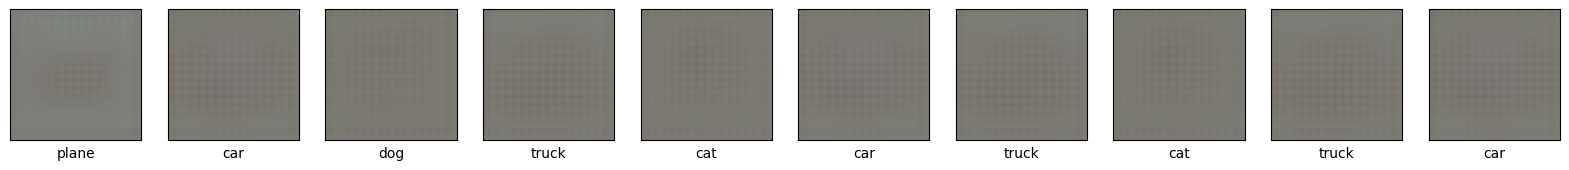

In [6]:
generator, amortiser = train(
    seed=SEED,
    n_classes=N_CLASSES,
    img_channels=IMG_CHANNELS,
    use_bias=USE_BIAS,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    error_momentum=ERROR_MOMENTUM,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    n_inference_steps=N_INFERENCE_STEPS,
    forward_energy_weight=FORWARD_ENERGY_WEIGHT
)

## Balancing generation and classification

$\alpha_f$ trades off classification accuracy against image reconstruction quality. With $\alpha_f = 10^{-5}$ the amortiser dominates the joint objective; raising $\alpha_f$ toward $1$ shifts the balance toward better generations at some cost to classification accuracy — matching the knob explored in the MLP [bePC](bepc.ipynb), Mixer [bePC](bepc_cifar_mixer.ipynb), and CNN [bPC](bidirectional_pc_cifar_cnn.ipynb) examples.

Iter 50, gen loss=368.005920, amort loss=0.442721, avg amort test accuracy=19.581329
Iter 100, gen loss=376.357422, amort loss=0.441518, avg amort test accuracy=20.192308
Iter 150, gen loss=381.805511, amort loss=0.437363, avg amort test accuracy=22.706329
Iter 200, gen loss=391.463074, amort loss=0.438070, avg amort test accuracy=23.627804
Iter 250, gen loss=468.519775, amort loss=0.463046, avg amort test accuracy=18.990385
Iter 300, gen loss=1503.700439, amort loss=0.438923, avg amort test accuracy=20.933493
Iter 350, gen loss=1018.263916, amort loss=0.431912, avg amort test accuracy=22.005209
Iter 400, gen loss=1033.860474, amort loss=0.421350, avg amort test accuracy=21.945112
Iter 450, gen loss=1009.467285, amort loss=0.437370, avg amort test accuracy=23.497597
Iter 500, gen loss=924.657288, amort loss=0.433802, avg amort test accuracy=21.454327
Iter 550, gen loss=934.347900, amort loss=0.445173, avg amort test accuracy=22.926683
Iter 600, gen loss=1192.993408, amort loss=0.421440

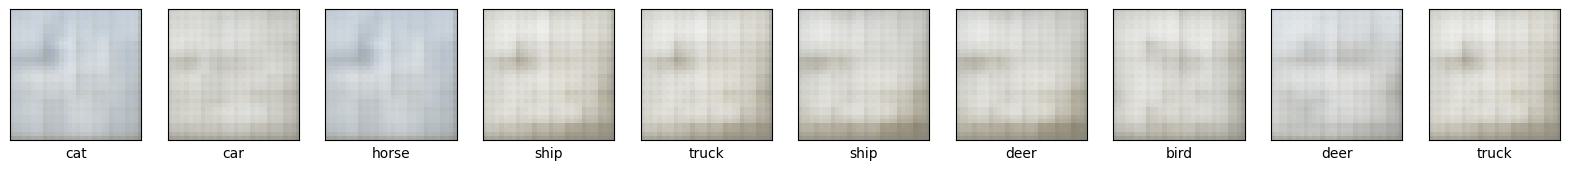

In [9]:
generator_balanced, amortiser_balanced = train(
    seed=SEED,
    n_classes=N_CLASSES,
    img_channels=IMG_CHANNELS,
    use_bias=USE_BIAS,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    error_momentum=ERROR_MOMENTUM,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    n_inference_steps=N_INFERENCE_STEPS,
    forward_energy_weight=1.0
)

## Notes and related examples

- This notebook is the VGG-5 CNN counterpart of [`bepc.ipynb`](bepc.ipynb) (MLP on MNIST) and [`bepc_cifar_mixer.ipynb`](bepc_cifar_mixer.ipynb) (MLP-Mixer on CIFAR-10), and the bePC counterpart of [`bidirectional_pc_cifar_cnn.ipynb`](bidirectional_pc_cifar_cnn.ipynb) (VGG-5 bPC on CIFAR-10).
- An incremental variant ("ibePC CNN") is a one-line change: move the `update_bepc_params` call inside the inference loop, analogous to how [`iepc.ipynb`](./iepc.ipynb) relates to [`epc.ipynb`](./epc.ipynb).
- Deeper stacks typically benefit from more `N_INFERENCE_STEPS`; the VGG-5 default of 8 follows the bPC CNN example.